# Digital Phenotyping Notebook – StudentLife & ExtraSensory 

This notebook works with the **original datasets**:

- StudentLife (`archive (3).zip`)
- ExtraSensory subset (`archive (4).zip`)

It will:
1. Inspect and clean **StudentLife** (PHQ-9 + activity).
2. Inspect and clean **ExtraSensory** (sensor features + activity labels).
3. Build simple baseline models:
   - Predict PHQ-9 from StudentLife activity.
   - Classify sitting vs not sitting from ExtraSensory.

In [1]:

# ============================================
# 0. Setup & Paths
# ============================================

import zipfile
import os
import re
import pandas as pd
import numpy as np
from collections import Counter

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

# ---- Adjust these file names to match your local files ----
STUDENTLIFE_ZIP  = "archive (3).zip"   # StudentLife dataset
EXTRASENSORY_ZIP = "archive (4).zip"   # ExtraSensory subset (user1, user2)



## 1. StudentLife – Explore Original Dataset

In [2]:

# ============================================
# 1. StudentLife: Explore ZIP structure
# ============================================

assert os.path.exists(STUDENTLIFE_ZIP), f"{STUDENTLIFE_ZIP} not found in current directory"

with zipfile.ZipFile(STUDENTLIFE_ZIP) as z:
    sl_files = z.namelist()

print("Number of files in StudentLife ZIP:", len(sl_files))
print("First 30 files:")
for f in sl_files[:30]:
    print("  ", f)


Number of files in StudentLife ZIP: 1984
First 30 files:
   dataset/EMA/EMA_definition.json
   dataset/EMA/response/Activity/Activity_u00.json
   dataset/EMA/response/Activity/Activity_u01.json
   dataset/EMA/response/Activity/Activity_u02.json
   dataset/EMA/response/Activity/Activity_u03.json
   dataset/EMA/response/Activity/Activity_u04.json
   dataset/EMA/response/Activity/Activity_u05.json
   dataset/EMA/response/Activity/Activity_u07.json
   dataset/EMA/response/Activity/Activity_u08.json
   dataset/EMA/response/Activity/Activity_u09.json
   dataset/EMA/response/Activity/Activity_u10.json
   dataset/EMA/response/Activity/Activity_u12.json
   dataset/EMA/response/Activity/Activity_u13.json
   dataset/EMA/response/Activity/Activity_u14.json
   dataset/EMA/response/Activity/Activity_u15.json
   dataset/EMA/response/Activity/Activity_u16.json
   dataset/EMA/response/Activity/Activity_u17.json
   dataset/EMA/response/Activity/Activity_u18.json
   dataset/EMA/response/Activity/Activity

### 1.1 StudentLife – PHQ-9 Structure & Missingness

In [3]:

# ============================================
# 1.1 StudentLife: PHQ-9 survey
# ============================================

with zipfile.ZipFile(STUDENTLIFE_ZIP) as z:
    phq_path_candidates = [f for f in z.namelist() if re.search(r"PHQ-9\.csv$", f, re.IGNORECASE)]
    print("PHQ-9 candidates:", phq_path_candidates)
    assert phq_path_candidates, "No PHQ-9 file found in StudentLife ZIP"
    phq_path = phq_path_candidates[0]
    
    with z.open(phq_path) as fh:
        phq = pd.read_csv(fh)

print("PHQ-9 shape:", phq.shape)
print("PHQ-9 columns:")
print(phq.columns.tolist())

# Identify ID column
uid_col = None
for c in phq.columns:
    if c.lower() in ("uid", "user", "user_id", "participant", "id"):
        uid_col = c
        break

print("\nID column:", uid_col)
if uid_col:
    print("Number of participants:", phq[uid_col].nunique())

# Inspect type column if present (e.g. pre/post)
if "type" in phq.columns:
    print("\nPHQ-9 type counts:")
    print(phq["type"].value_counts())

print("\nOverall missingness per column in PHQ-9:")
display(phq.isna().mean().sort_values(ascending=False))


PHQ-9 candidates: ['dataset/survey/PHQ-9.csv']
PHQ-9 shape: (84, 12)
PHQ-9 columns:
['uid', 'type', 'Little interest or pleasure in doing things', 'Feeling down, depressed, hopeless.', 'Trouble falling or staying asleep, or sleeping too much.', 'Feeling tired or having little energy', 'Poor appetite or overeating', 'Feeling bad about yourself or that you are a failure or have let yourself or your family down', 'Trouble concentrating on things, such as reading the newspaper or watching television', 'Moving or speaking so slowly that other people could have noticed. Or the opposite being so figety or restless that you have been moving around a lot more than usual', 'Thoughts that you would be better off dead, or of hurting yourself', 'Response']

ID column: uid
Number of participants: 46

PHQ-9 type counts:
type
pre     46
post    38
Name: count, dtype: int64

Overall missingness per column in PHQ-9:


Response                                                                                                                                                                 0.059524
uid                                                                                                                                                                      0.000000
type                                                                                                                                                                     0.000000
Little interest or pleasure in doing things                                                                                                                              0.000000
Feeling down, depressed, hopeless.                                                                                                                                       0.000000
Trouble falling or staying asleep, or sleeping too much.                                                      

### 1.2 StudentLife – Clean PHQ-9 and Compute `phq_total`

In [4]:

# ============================================
# 1.2 StudentLife: Clean PHQ-9 and compute phq_total
# ============================================

ignore_cols = {"type", "Response"}
# Try to detect item columns named phq1..phq9
phq_item_cols = [c for c in phq.columns if re.fullmatch(r"(?i)phq[1-9]", c)]

# If they don't exist, treat all non-ID, non-ignore columns as items
if not phq_item_cols:
    phq_item_cols = [c for c in phq.columns if c not in (ignore_cols | {uid_col})]

print("PHQ item columns:", phq_item_cols)

# Typical PHQ-9 text mapping, if items are text
mapping = {
    "Not at all": 0,
    "Several days": 1,
    "More than half the days": 2,
    "Nearly every day": 3,
}

phq_num = phq.copy()

for c in phq_item_cols:
    if phq_num[c].dtype == object:
        phq_num[c] = phq_num[c].map(mapping)

print("\nMissingness per PHQ item (after mapping where possible):")
print(phq_num[phq_item_cols].isna().mean().sort_values(ascending=False))

# Drop rows where too many items are missing (e.g. >3 missing)
max_missing_items = 3
valid_mask = phq_num[phq_item_cols].isna().sum(axis=1) <= max_missing_items
phq_clean = phq_num[valid_mask].copy()

# Impute remaining missing with median
for c in phq_item_cols:
    phq_clean[c] = phq_clean[c].fillna(phq_clean[c].median())

# Compute PHQ total score
phq_clean["phq_total"] = phq_clean[phq_item_cols].sum(axis=1)

print("\nPHQ cleaned shape:", phq_clean.shape)
phq_clean[[uid_col, "phq_total"] + phq_item_cols].head()


PHQ item columns: ['Little interest or pleasure in doing things', 'Feeling down, depressed, hopeless.', 'Trouble falling or staying asleep, or sleeping too much.', 'Feeling tired or having little energy', 'Poor appetite or overeating', 'Feeling bad about yourself or that you are a failure or have let yourself or your family down', 'Trouble concentrating on things, such as reading the newspaper or watching television', 'Moving or speaking so slowly that other people could have noticed. Or the opposite being so figety or restless that you have been moving around a lot more than usual', 'Thoughts that you would be better off dead, or of hurting yourself']

Missingness per PHQ item (after mapping where possible):
Little interest or pleasure in doing things                                                                                                                              0.0
Feeling down, depressed, hopeless.                                                                          

,uid,phq_total,Little interest or pleasure in doing things,"Feeling down, depressed, hopeless.","Trouble falling or staying asleep, or sleeping too much.",Feeling tired or having little energy,Poor appetite or overeating,Feeling bad about yourself or that you are a failure or have let yourself or your family down,"Trouble concentrating on things, such as reading the newspaper or watching television",Moving or speaking so slowly that other people could have noticed. Or the opposite being so figety or restless that you have been moving around a lot more than usual,"Thoughts that you would be better off dead, or of hurting yourself"
0,u00,2,0,1,0,1,0,0,0,0,0
1,u01,5,1,1,1,1,0,1,0,0,0
2,u02,13,2,1,2,2,2,1,1,2,0
3,u03,2,0,1,0,0,0,0,0,1,0
4,u04,6,1,1,0,1,1,1,1,0,0


In [5]:

# PHQ-9 severity categories

def phq_severity(score):
    if score <= 4:
        return "None-minimal"
    elif score <= 9:
        return "Mild"
    elif score <= 14:
        return "Moderate"
    elif score <= 19:
        return "Moderately severe"
    else:
        return "Severe"

phq_clean["phq_severity"] = phq_clean["phq_total"].apply(phq_severity)
phq_clean[[uid_col, "phq_total", "phq_severity"]].head()


,uid,phq_total,phq_severity
0,u00,2,None-minimal
1,u01,5,Mild
2,u02,13,Moderate
3,u03,2,None-minimal
4,u04,6,Mild


### 1.3 StudentLife – Load & Combine All Activity Files

In [6]:

# ============================================
# 1.3 StudentLife: Load & combine all activity files
# ============================================

with zipfile.ZipFile(STUDENTLIFE_ZIP) as z:
    sl_files = z.namelist()
    act_files = [f for f in sl_files if re.search(r"sensing/activity/activity_u\d+\.csv$", f)]

print("Number of activity files (users):", len(act_files))
print("First 5 activity files:")
for f in act_files[:5]:
    print("  ", f)

all_activity = []

with zipfile.ZipFile(STUDENTLIFE_ZIP) as z:
    for f in act_files:
        with z.open(f) as fh:
            df = pd.read_csv(fh)
        
        # Standardise column names
        df.columns = [c.strip().replace(" ", "_") for c in df.columns]
        
        # Detect columns
        time_col = None
        for c in df.columns:
            if "time" in c.lower():
                time_col = c
                break
        
        act_col = None
        for c in df.columns:
            if "activity" in c.lower():
                act_col = c
                break
        
        if time_col is None or act_col is None:
            continue
        
        # Extract user_id from filename
        m = re.search(r"activity_u(\d+)\.csv$", f)
        user_id = f"u{m.group(1)}" if m else f
        
        tmp = df[[time_col, act_col]].copy()
        tmp.rename(columns={time_col: "timestamp", act_col: "activity_inference"}, inplace=True)
        tmp["user_id"] = user_id
        
        all_activity.append(tmp)

activity = pd.concat(all_activity, ignore_index=True)
print("Combined activity shape:", activity.shape)
activity.head()


Number of activity files (users): 49
First 5 activity files:
   dataset/sensing/activity/activity_u00.csv
   dataset/sensing/activity/activity_u01.csv
   dataset/sensing/activity/activity_u02.csv
   dataset/sensing/activity/activity_u03.csv
   dataset/sensing/activity/activity_u04.csv
Combined activity shape: (22842191, 3)


,timestamp,activity_inference,user_id
0,1364356801,0,u00
1,1364356804,0,u00
2,1364356807,0,u00
3,1364356809,0,u00
4,1364356992,0,u00


### 1.4 StudentLife – Daily Activity Features per User

In [7]:

# ============================================
# 1.4 StudentLife: Daily activity features
# ============================================

# Convert timestamp to datetime (adjust 'unit' if necessary)
activity["timestamp"] = pd.to_datetime(activity["timestamp"], unit="s", errors="coerce")
activity["date"] = activity["timestamp"].dt.date

print("Unique activity codes:", activity["activity_inference"].unique())

# One-hot encode activities and aggregate per user/day (mean = proportion)
act_dummies = pd.get_dummies(activity["activity_inference"], prefix="act")

activity_daily = (
    pd.concat([activity[["user_id", "date"]], act_dummies], axis=1)
    .groupby(["user_id", "date"], as_index=False)
    .mean()
)

print("Daily activity shape:", activity_daily.shape)
activity_daily.head()


Unique activity codes: [0 3 1 2]
Daily activity shape: (2883, 6)


,user_id,date,act_0,act_1,act_2,act_3
0,u00,2013-03-27,0.812952,0.110090,0.046536,0.030422
1,u00,2013-03-28,0.910270,0.050039,0.022662,0.017029
2,u00,2013-03-29,0.838184,0.114400,0.013046,0.034370
3,u00,2013-03-30,0.885659,0.075657,0.006839,0.031844
4,u00,2013-03-31,0.808346,0.090580,0.076462,0.024613


### 1.5 StudentLife – Merge Daily Activity with PHQ-9

In [8]:

# ============================================
# 1.5 StudentLife: Merge PHQ with daily activity
# ============================================

# Adjust this mapping if PHQ uid format differs
phq_users = phq_clean.copy()
phq_users["user_id"] = phq_users[uid_col].astype(str)

merged = activity_daily.merge(
    phq_users[["user_id", "phq_total", "phq_severity"]],
    on="user_id",
    how="inner"
)

print("Merged daily+PHQ shape:", merged.shape)
merged.head()


Merged daily+PHQ shape: (5022, 8)


,user_id,date,act_0,act_1,act_2,act_3,phq_total,phq_severity
0,u00,2013-03-27,0.812952,0.110090,0.046536,0.030422,2,None-minimal
1,u00,2013-03-27,0.812952,0.110090,0.046536,0.030422,3,None-minimal
2,u00,2013-03-28,0.910270,0.050039,0.022662,0.017029,2,None-minimal
3,u00,2013-03-28,0.910270,0.050039,0.022662,0.017029,3,None-minimal
4,u00,2013-03-29,0.838184,0.114400,0.013046,0.034370,2,None-minimal


In [9]:

# ============================================
# 1.6 Save cleaned StudentLife outputs
# ============================================

os.makedirs("cleaned", exist_ok=True)

phq_clean.to_csv("cleaned/studentlife_phq_clean.csv", index=False)
activity_daily.to_csv("cleaned/studentlife_activity_daily.csv", index=False)
merged.to_csv("cleaned/studentlife_daily_with_phq.csv", index=False)

print("Saved:")
print("  cleaned/studentlife_phq_clean.csv")
print("  cleaned/studentlife_activity_daily.csv")
print("  cleaned/studentlife_daily_with_phq.csv")


Saved:
  cleaned/studentlife_phq_clean.csv
  cleaned/studentlife_activity_daily.csv
  cleaned/studentlife_daily_with_phq.csv


## 2. ExtraSensory – Clean Features & Labels

In [10]:

# ============================================
# 2.1 ExtraSensory: List CSV files
# ============================================

assert os.path.exists(EXTRASENSORY_ZIP), f"{EXTRASENSORY_ZIP} not found"

with zipfile.ZipFile(EXTRASENSORY_ZIP) as z:
    es_files = [f for f in z.namelist() if f.endswith(".csv")]

print("ExtraSensory CSV files:")
for f in es_files:
    print("  ", f)


ExtraSensory CSV files:
   user1.features_labels.csv
   user2.features_labels.csv


In [11]:

# ============================================
# 2.2 ExtraSensory: Clean & keep core labels
# ============================================

core_labels = [
    "label:SITTING",
    "label:LYING_DOWN",
    "label:FIX_walking",
    "label:FIX_running",
    "label:SLEEPING",
    "label:LOC_home",
    "label:LOC_main_workplace",
    "label:PHONE_IN_POCKET",
]

all_es = []

with zipfile.ZipFile(EXTRASENSORY_ZIP) as z:
    for f in es_files:
        with z.open(f) as fh:
            df = pd.read_csv(fh)
        
        print("\n=== Cleaning ExtraSensory file:", f, "===")
        print("Original shape:", df.shape)
        
        # Drop all-NaN columns
        null_frac = df.isna().mean()
        all_nan_cols = null_frac[null_frac == 1.0].index.tolist()
        df = df.drop(columns=all_nan_cols)
        print("Dropped all-NaN columns:", len(all_nan_cols))
        
        label_cols = [c for c in df.columns if c.startswith("label:")]
        feat_cols = [c for c in df.columns if not c.startswith("label:")]
        
        used_labels = [c for c in core_labels if c in label_cols]
        print("Using label columns:", used_labels)
        
        if not used_labels:
            print("Warning: no core labels found, skipping file")
            continue
        
        # Drop rows with no positive label among used_labels
        label_matrix = df[used_labels]
        keep_mask = label_matrix.sum(axis=1) > 0
        df_clean = df.loc[keep_mask, feat_cols + used_labels].copy()
        
        # Add user_id from filename if possible
        m = re.search(r"(user\d+)", f)
        user_id = m.group(1) if m else f
        df_clean["user_id"] = user_id
        
        print("Cleaned shape:", df_clean.shape)
        all_es.append(df_clean)

extrasensory_clean = pd.concat(all_es, ignore_index=True)
print("\nCombined ExtraSensory shape:", extrasensory_clean.shape)
extrasensory_clean.head()



=== Cleaning ExtraSensory file: user1.features_labels.csv ===
Original shape: (2685, 278)
Dropped all-NaN columns: 17
Using label columns: ['label:SITTING', 'label:LYING_DOWN', 'label:FIX_walking', 'label:FIX_running', 'label:SLEEPING', 'label:LOC_home', 'label:LOC_main_workplace', 'label:PHONE_IN_POCKET']
Cleaned shape: (2674, 229)

=== Cleaning ExtraSensory file: user2.features_labels.csv ===
Original shape: (8845, 278)
Dropped all-NaN columns: 25
Using label columns: ['label:SITTING', 'label:LYING_DOWN', 'label:FIX_walking', 'label:SLEEPING', 'label:LOC_home', 'label:LOC_main_workplace']
Cleaned shape: (7177, 229)

Combined ExtraSensory shape: (9851, 234)


,timestamp,raw_acc:magnitude_stats:mean,raw_acc:magnitude_stats:std,raw_acc:magnitude_stats:moment3,raw_acc:magnitude_stats:moment4,raw_acc:magnitude_stats:percentile25,raw_acc:magnitude_stats:percentile50,raw_acc:magnitude_stats:percentile75,raw_acc:magnitude_stats:value_entropy,raw_acc:magnitude_stats:time_entropy,raw_acc:magnitude_spectrum:log_energy_band0,raw_acc:magnitude_spectrum:log_energy_band1,raw_acc:magnitude_spectrum:log_energy_band2,raw_acc:magnitude_spectrum:log_energy_band3,raw_acc:magnitude_spectrum:log_energy_band4,raw_acc:magnitude_spectrum:spectral_entropy,raw_acc:magnitude_autocorrelation:period,raw_acc:magnitude_autocorrelation:normalized_ac,raw_acc:3d:mean_x,raw_acc:3d:mean_y,raw_acc:3d:mean_z,raw_acc:3d:std_x,raw_acc:3d:std_y,raw_acc:3d:std_z,raw_acc:3d:ro_xy,raw_acc:3d:ro_xz,raw_acc:3d:ro_yz,proc_gyro:magnitude_stats:mean,proc_gyro:magnitude_stats:std,proc_gyro:magnitude_stats:moment3,proc_gyro:magnitude_stats:moment4,proc_gyro:magnitude_stats:percentile25,proc_gyro:magnitude_stats:percentile50,proc_gyro:magnitude_stats:percentile75,proc_gyro:magnitude_stats:value_entropy,proc_gyro:magnitude_stats:time_entropy,proc_gyro:magnitude_spectrum:log_energy_band0,proc_gyro:magnitude_spectrum:log_energy_band1,proc_gyro:magnitude_spectrum:log_energy_band2,proc_gyro:magnitude_spectrum:log_energy_band3,proc_gyro:magnitude_spectrum:log_energy_band4,proc_gyro:magnitude_spectrum:spectral_entropy,proc_gyro:magnitude_autocorrelation:period,proc_gyro:magnitude_autocorrelation:normalized_ac,proc_gyro:3d:mean_x,proc_gyro:3d:mean_y,proc_gyro:3d:mean_z,proc_gyro:3d:std_x,proc_gyro:3d:std_y,proc_gyro:3d:std_z,proc_gyro:3d:ro_xy,proc_gyro:3d:ro_xz,proc_gyro:3d:ro_yz,raw_magnet:magnitude_stats:mean,raw_magnet:magnitude_stats:std,raw_magnet:magnitude_stats:moment3,raw_magnet:magnitude_stats:moment4,raw_magnet:magnitude_stats:percentile25,raw_magnet:magnitude_stats:percentile50,raw_magnet:magnitude_stats:percentile75,...,audio_naive:mfcc8:std,audio_naive:mfcc9:std,audio_naive:mfcc10:std,audio_naive:mfcc11:std,audio_naive:mfcc12:std,audio_properties:max_abs_value,audio_properties:normalization_multiplier,discrete:app_state:is_active,discrete:app_state:is_inactive,discrete:app_state:is_background,discrete:app_state:missing,discrete:battery_plugged:is_ac,discrete:battery_plugged:is_usb,discrete:battery_plugged:is_wireless,discrete:battery_plugged:missing,discrete:battery_state:is_unknown,discrete:battery_state:is_unplugged,discrete:battery_state:is_not_charging,discrete:battery_state:is_discharging,discrete:battery_state:is_charging,discrete:battery_state:is_full,discrete:battery_state:missing,discrete:on_the_phone:is_False,discrete:on_the_phone:is_True,discrete:on_the_phone:missing,discrete:ringer_mode:is_normal,discrete:ringer_mode:is_silent_no_vibrate,discrete:ringer_mode:is_silent_with_vibrate,discrete:ringer_mode:missing,discrete:wifi_status:is_not_reachable,discrete:wifi_status:is_reachable_via_wifi,discrete:wifi_status:is_reachable_via_wwan,discrete:wifi_status:missing,lf_measurements:light,lf_measurements:pressure,lf_measurements:proximity_cm,lf_measurements:battery_level,discrete:time_of_day:between0and6,discrete:time_of_day:between3and9,discrete:time_of_day:between6and12,discrete:time_of_day:between9and15,discrete:time_of_day:between12and18,discrete:time_of_day:between15and21,discrete:time_of_day:between18and24,discrete:time_of_day:between21and3,label_source,label:SITTING,label:LYING_DOWN,label:FIX_walking,label:FIX_running,label:SLEEPING,label:LOC_home,label:LOC_main_workplace,label:PHONE_IN_POCKET,user_id,location:min_altitude,location:max_altitude,location:best_vertical_accuracy,lf_measurements:proximity,lf_measurements:screen_brightness
0,1464129912,1.011438,0.012573,0.023013,0.041240,1.006184,1.010868,1.016028,0.935099,6.684536,5.045404,0.002765,0.009658,0.012629,0.099805,0.432150,4.100449,0.162703,-0.029586,0.002907,1.010972,0.005533,0.005385,0.012524,0.088952,-0.191380,-0.160822,0.014675,0.019652,0.044390,0.069752,0

In [12]:

# ============================================
# 2.3 ExtraSensory: Normalise numeric features (optional)
# ============================================

feat_cols_clean = [c for c in extrasensory_clean.columns if not c.startswith("label:") and c != "user_id"]
num_cols = [c for c in feat_cols_clean if np.issubdtype(extrasensory_clean[c].dtype, np.number)]

extrasensory_norm = extrasensory_clean.copy()
for c in num_cols:
    mean = extrasensory_norm[c].mean()
    std = extrasensory_norm[c].std()
    if std > 0:
        extrasensory_norm[c] = (extrasensory_norm[c] - mean) / std

extrasensory_norm.head()


,timestamp,raw_acc:magnitude_stats:mean,raw_acc:magnitude_stats:std,raw_acc:magnitude_stats:moment3,raw_acc:magnitude_stats:moment4,raw_acc:magnitude_stats:percentile25,raw_acc:magnitude_stats:percentile50,raw_acc:magnitude_stats:percentile75,raw_acc:magnitude_stats:value_entropy,raw_acc:magnitude_stats:time_entropy,raw_acc:magnitude_spectrum:log_energy_band0,raw_acc:magnitude_spectrum:log_energy_band1,raw_acc:magnitude_spectrum:log_energy_band2,raw_acc:magnitude_spectrum:log_energy_band3,raw_acc:magnitude_spectrum:log_energy_band4,raw_acc:magnitude_spectrum:spectral_entropy,raw_acc:magnitude_autocorrelation:period,raw_acc:magnitude_autocorrelation:normalized_ac,raw_acc:3d:mean_x,raw_acc:3d:mean_y,raw_acc:3d:mean_z,raw_acc:3d:std_x,raw_acc:3d:std_y,raw_acc:3d:std_z,raw_acc:3d:ro_xy,raw_acc:3d:ro_xz,raw_acc:3d:ro_yz,proc_gyro:magnitude_stats:mean,proc_gyro:magnitude_stats:std,proc_gyro:magnitude_stats:moment3,proc_gyro:magnitude_stats:moment4,proc_gyro:magnitude_stats:percentile25,proc_gyro:magnitude_stats:percentile50,proc_gyro:magnitude_stats:percentile75,proc_gyro:magnitude_stats:value_entropy,proc_gyro:magnitude_stats:time_entropy,proc_gyro:magnitude_spectrum:log_energy_band0,proc_gyro:magnitude_spectrum:log_energy_band1,proc_gyro:magnitude_spectrum:log_energy_band2,proc_gyro:magnitude_spectrum:log_energy_band3,proc_gyro:magnitude_spectrum:log_energy_band4,proc_gyro:magnitude_spectrum:spectral_entropy,proc_gyro:magnitude_autocorrelation:period,proc_gyro:magnitude_autocorrelation:normalized_ac,proc_gyro:3d:mean_x,proc_gyro:3d:mean_y,proc_gyro:3d:mean_z,proc_gyro:3d:std_x,proc_gyro:3d:std_y,proc_gyro:3d:std_z,proc_gyro:3d:ro_xy,proc_gyro:3d:ro_xz,proc_gyro:3d:ro_yz,raw_magnet:magnitude_stats:mean,raw_magnet:magnitude_stats:std,raw_magnet:magnitude_stats:moment3,raw_magnet:magnitude_stats:moment4,raw_magnet:magnitude_stats:percentile25,raw_magnet:magnitude_stats:percentile50,raw_magnet:magnitude_stats:percentile75,...,audio_naive:mfcc8:std,audio_naive:mfcc9:std,audio_naive:mfcc10:std,audio_naive:mfcc11:std,audio_naive:mfcc12:std,audio_properties:max_abs_value,audio_properties:normalization_multiplier,discrete:app_state:is_active,discrete:app_state:is_inactive,discrete:app_state:is_background,discrete:app_state:missing,discrete:battery_plugged:is_ac,discrete:battery_plugged:is_usb,discrete:battery_plugged:is_wireless,discrete:battery_plugged:missing,discrete:battery_state:is_unknown,discrete:battery_state:is_unplugged,discrete:battery_state:is_not_charging,discrete:battery_state:is_discharging,discrete:battery_state:is_charging,discrete:battery_state:is_full,discrete:battery_state:missing,discrete:on_the_phone:is_False,discrete:on_the_phone:is_True,discrete:on_the_phone:missing,discrete:ringer_mode:is_normal,discrete:ringer_mode:is_silent_no_vibrate,discrete:ringer_mode:is_silent_with_vibrate,discrete:ringer_mode:missing,discrete:wifi_status:is_not_reachable,discrete:wifi_status:is_reachable_via_wifi,discrete:wifi_status:is_reachable_via_wwan,discrete:wifi_status:missing,lf_measurements:light,lf_measurements:pressure,lf_measurements:proximity_cm,lf_measurements:battery_level,discrete:time_of_day:between0and6,discrete:time_of_day:between3and9,discrete:time_of_day:between6and12,discrete:time_of_day:between9and15,discrete:time_of_day:between12and18,discrete:time_of_day:between15and21,discrete:time_of_day:between18and24,discrete:time_of_day:between21and3,label_source,label:SITTING,label:LYING_DOWN,label:FIX_walking,label:FIX_running,label:SLEEPING,label:LOC_home,label:LOC_main_workplace,label:PHONE_IN_POCKET,user_id,location:min_altitude,location:max_altitude,location:best_vertical_accuracy,lf_measurements:proximity,lf_measurements:screen_brightness
0,1.604022,0.216327,-0.171682,0.029523,-0.049251,0.417422,0.318954,-0.009661,-1.887121,0.182526,0.246149,-0.221480,-0.260749,-0.247622,-0.160941,-0.192308,0.463208,0.337017,-0.216459,-0.109608,1.396643,-0.279160,-0.282057,-0.224251,0.373800,-0.932481,-0.505533,-0.226952,-0.258899,-0.197

In [13]:

# ============================================
# 2.4 Save cleaned ExtraSensory outputs
# ============================================

os.makedirs("cleaned", exist_ok=True)

extrasensory_clean.to_csv("cleaned/extrasensory_clean_core_labels.csv", index=False)
extrasensory_norm.to_csv("cleaned/extrasensory_clean_core_labels_normalized.csv", index=False)

print("Saved:")
print("  cleaned/extrasensory_clean_core_labels.csv")
print("  cleaned/extrasensory_clean_core_labels_normalized.csv")


Saved:
  cleaned/extrasensory_clean_core_labels.csv
  cleaned/extrasensory_clean_core_labels_normalized.csv


## 3. Baseline Model – Predict PHQ-9 from StudentLife Activity

StudentLife merged daily+PHQ shape: (5022, 8)
Activity feature columns: ['act_0', 'act_1', 'act_2', 'act_3']
Aggregated per user shape: (46, 6)
=== StudentLife PHQ-9 Regression Results ===
Mean Absolute Error (MAE): 4.387
R² Score: -0.542

Top activity features:
act_3    0.369434
act_0    0.246343
act_1    0.200017
act_2    0.184205
dtype: float64


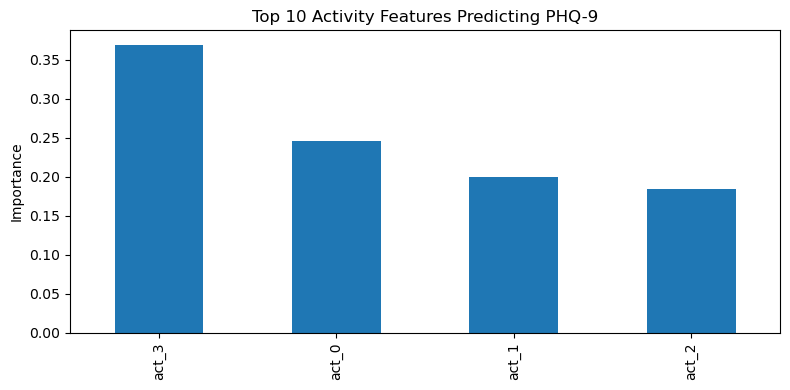

In [14]:

# ============================================
# 3.1 Load merged StudentLife daily data
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

sl_daily = pd.read_csv("cleaned/studentlife_daily_with_phq.csv")
print("StudentLife merged daily+PHQ shape:", sl_daily.shape)
sl_daily.head()

# Identify activity feature columns
act_cols = [c for c in sl_daily.columns if c.startswith("act_")]
print("Activity feature columns:", act_cols)

# Aggregate per user (mean daily distribution)
sl_user = (
    sl_daily.groupby("user_id", as_index=False)[act_cols + ["phq_total"]]
    .mean()
)

print("Aggregated per user shape:", sl_user.shape)
sl_user.head()

X = sl_user[act_cols].values
y = sl_user["phq_total"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

rf_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_reg.fit(X_train, y_train)
y_pred = rf_reg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("=== StudentLife PHQ-9 Regression Results ===")
print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"R² Score: {r2:.3f}")

# Feature importance
importances = rf_reg.feature_importances_
feat_imp = pd.Series(importances, index=act_cols).sort_values(ascending=False)

print("\nTop activity features:")
print(feat_imp.head(10))

plt.figure(figsize=(8, 4))
feat_imp.head(10).plot(kind="bar")
plt.title("Top 10 Activity Features Predicting PHQ-9")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


## 4. Baseline Model – Classify Sitting vs Not Sitting (ExtraSensory)

In [15]:

# ============================================
# 4.1 Load cleaned ExtraSensory data and fix NaNs in y
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

es = pd.read_csv("cleaned/extrasensory_clean_core_labels_normalized.csv")
print("ExtraSensory cleaned shape:", es.shape)

target_label = "label:SITTING"
assert target_label in es.columns, f"{target_label} not found in columns"

# 1) Drop rows with NaN in the target label
nan_target_count = es[target_label].isna().sum()
print(f"Rows with NaN in {target_label}: {nan_target_count}")

es = es[es[target_label].notna()].copy()
print("Shape after dropping NaN labels:", es.shape)

# 2) Define feature columns (non-label, non-user_id)
feature_cols = [c for c in es.columns if (not c.startswith("label:")) and (c != "user_id")]

# Fill NaNs in features with 0
X = es[feature_cols].fillna(0).values

# Target: ensure int 0/1
y = es[target_label].astype(int).values

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Class balance (0=not sitting, 1=sitting):")
print(pd.Series(y).value_counts())

# 3) Train/test split with stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 4) Baseline Logistic Regression
clf = LogisticRegression(max_iter=1000, n_jobs=-1)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)

print("=== ExtraSensory Sitting Classification Results ===")
print(f"Accuracy: {acc:.3f}")
print(f"F1-score: {f1:.3f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))


ExtraSensory cleaned shape: (9851, 234)
Rows with NaN in label:SITTING: 1888
Shape after dropping NaN labels: (7963, 234)
Number of samples: 7963
Number of features: 225
Class balance (0=not sitting, 1=sitting):
0    4726
1    3237
Name: count, dtype: int64
=== ExtraSensory Sitting Classification Results ===
Accuracy: 0.912
F1-score: 0.893

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      1418
           1       0.89      0.90      0.89       971

    accuracy                           0.91      2389
   macro avg       0.91      0.91      0.91      2389
weighted avg       0.91      0.91      0.91      2389

Confusion matrix:
[[1307  111]
 [  99  872]]


## 5. Digital Indicators (Translate Behavior/Mental-Health Signals to Features)

Digital indicators = measurable numeric features extracted from sensor/activity data that represent
behavioral or mental-health related signals.

We apply indicators to:

### StudentLife (daily activity + PHQ-9)
Behavior signal → Digital indicator (feature)
- **Low movement / inactivity** → `sedentary_share_proxy` (act_0 + act_1)
- **High movement / engagement** → `active_share_proxy` (act_2 + act_3)
- **Behavioral variety vs monotony** → `activity_entropy`
- **Rigid routine / one-mode days** → `dominant_activity_share`
- **Instability / irregular routine across days** → per-user `std` of the daily indicators

### ExtraSensory (binary activity/context labels)
Behavior signal → Digital indicator (feature)
- **Sedentary lifestyle** → `SITTING_rate`, `LYING_DOWN_rate`
- **Physical activity level** → `FIX_walking_rate`, `FIX_running_rate`
- **Sleep tendency / low arousal** → `SLEEPING_rate`
- **Home-staying / possible withdrawal** → `LOC_home_rate`
- **Workplace attendance / structured routine** → `LOC_main_workplace_rate`
- **Phone-carrying habit** → `PHONE_IN_POCKET_rate`
- **Active vs sedentary balance** → `active_to_sedentary_ratio`
- **Context diversity vs repetitiveness** → `label_entropy`
- **Home minus work time** → `home_minus_work_rate` (proxy for isolation)


In [17]:
# ============================================
# 5.1 StudentLife: Digital Indicators
# ============================================

sl_daily_feat = pd.read_csv("cleaned/studentlife_activity_daily.csv")
print("StudentLife daily activity shape:", sl_daily_feat.shape)
display(sl_daily_feat.head())

act_cols = [c for c in sl_daily_feat.columns if c.startswith("act_")]
assert act_cols, "No act_ columns found. Run StudentLife cleaning first."

def activity_entropy(row, cols):
    p = row[cols].values.astype(float)
    p = np.clip(p, 1e-12, 1.0)
    return float(-(p * np.log(p)).sum())

sl_ind = sl_daily_feat.copy()

# Indicator 1: Behavioral variety
sl_ind["activity_entropy"] = sl_ind.apply(lambda r: activity_entropy(r, act_cols), axis=1)

# Indicator 2: Routine rigidity (single-mode days)
sl_ind["dominant_activity_share"] = sl_ind[act_cols].max(axis=1)

# Indicator 3: Sedentary share proxy (low-movement codes)
sed_cols = [c for c in act_cols if c in ("act_0", "act_1")]
sl_ind["sedentary_share_proxy"] = sl_ind[sed_cols].sum(axis=1) if sed_cols else np.nan

# Indicator 4: Active share proxy (high-movement codes)
hi_cols = [c for c in act_cols if c in ("act_2", "act_3")]
sl_ind["active_share_proxy"] = sl_ind[hi_cols].sum(axis=1) if hi_cols else np.nan

print("\nDaily StudentLife indicators preview:")
display(sl_ind.head())

# Aggregate per participant = indicator mean + variability
sl_user_ind = (
    sl_ind.groupby("user_id")[
        ["activity_entropy", "dominant_activity_share",
         "sedentary_share_proxy", "active_share_proxy"]
    ].agg(["mean", "std"])
)

sl_user_ind.columns = ["_".join(c) for c in sl_user_ind.columns]
sl_user_ind = sl_user_ind.reset_index()

print("\nStudentLife indicators per user:")
display(sl_user_ind.head())

# Save
sl_ind.to_csv("cleaned/studentlife_indicators_daily.csv", index=False)
sl_user_ind.to_csv("cleaned/studentlife_indicators_user.csv", index=False)

print("Saved:")
print("  cleaned/studentlife_indicators_daily.csv")
print("  cleaned/studentlife_indicators_user.csv")


StudentLife daily activity shape: (2883, 6)


,user_id,date,act_0,act_1,act_2,act_3
0,u00,2013-03-27,0.812952,0.110090,0.046536,0.030422
1,u00,2013-03-28,0.910270,0.050039,0.022662,0.017029
2,u00,2013-03-29,0.838184,0.114400,0.013046,0.034370
3,u00,2013-03-30,0.885659,0.075657,0.006839,0.031844
4,u00,2013-03-31,0.808346,0.090580,0.076462,0.024613



Daily StudentLife indicators preview:


,user_id,date,act_0,act_1,act_2,act_3,activity_entropy,dominant_activity_share,sedentary_share_proxy,active_share_proxy
0,u00,2013-03-27,0.812952,0.110090,0.046536,0.030422,0.660260,0.812952,0.923042,0.076958
1,u00,2013-03-28,0.910270,0.050039,0.022662,0.017029,0.390622,0.910270,0.960309,0.039691
2,u00,2013-03-29,0.838184,0.114400,0.013046,0.034370,0.568437,0.838184,0.952584,0.047416
3,u00,2013-03-30,0.885659,0.075657,0.006839,0.031844,0.446709,0.885659,0.961317,0.038683
4,u00,2013-03-31,0.808346,0.090580,0.076462,0.024613,0.677275,0.808346,0.898926,0.101074



StudentLife indicators per user:


,user_id,activity_entropy_mean,activity_entropy_std,dominant_activity_share_mean,dominant_activity_share_std,sedentary_share_proxy_mean,sedentary_share_proxy_std,active_share_proxy_mean,active_share_proxy_std
0,u00,0.487922,0.207079,0.862789,0.082776,0.936248,0.052641,0.063752,0.052641
1,u01,0.339574,0.128411,0.920276,0.041363,0.965880,0.018063,0.034120,0.018063
2,u02,0.317320,0.095116,0.921551,0.030209,0.976838,0.017502,0.023162,0.017502
3,u03,0.081068,0.093166,0.983813,0.020266,0.995170,0.006948,0.004830,0.006948
4,u04,0.495306,0.129256,0.862795,0.057079,0.934423,0.057567,0.065577,0.057567


Saved:
  cleaned/studentlife_indicators_daily.csv
  cleaned/studentlife_indicators_user.csv


In [18]:
# ============================================
# 5.2 ExtraSensory: Digital Indicators
# ============================================



es_clean = pd.read_csv("cleaned/extrasensory_clean_core_labels_normalized.csv")
print("ExtraSensory cleaned shape:", es_clean.shape)

label_cols = [c for c in es_clean.columns if c.startswith("label:")]
print("Label columns found:", label_cols)

es_labels = es_clean[label_cols].fillna(0).astype(int)
es_ind = es_clean.copy()

# Indicator 1: Per-label prevalence rates
for c in label_cols:
    es_ind[c.replace("label:", "") + "_rate"] = es_labels[c]

rate_cols = [c for c in es_ind.columns if c.endswith("_rate")]

# Indicator 2: Active vs sedentary balance
sed_rate = 0
act_rate = 0
if "label:SITTING" in es_labels: sed_rate += es_labels["label:SITTING"]
if "label:LYING_DOWN" in es_labels: sed_rate += es_labels["label:LYING_DOWN"]
if "label:FIX_walking" in es_labels: act_rate += es_labels["label:FIX_walking"]
if "label:FIX_running" in es_labels: act_rate += es_labels["label:FIX_running"]

es_ind["active_to_sedentary_ratio"] = (act_rate + 1e-6) / (sed_rate + 1e-6)

# Indicator 3: Context diversity (entropy over labels)
def label_entropy_row(row):
    p = row.values.astype(float)
    total = p.sum()
    if total == 0:
        return 0.0
    p = p / total
    p = np.clip(p, 1e-12, 1.0)
    return float(-(p * np.log(p)).sum())

es_ind["label_entropy"] = es_labels.apply(label_entropy_row, axis=1)

# Indicator 4: Home minus Work (withdrawal proxy)
if "label:LOC_home" in es_labels and "label:LOC_main_workplace" in es_labels:
    es_ind["home_minus_work_rate"] = (
        es_labels["label:LOC_home"] - es_labels["label:LOC_main_workplace"]
    )
else:
    es_ind["home_minus_work_rate"] = np.nan

print("\nExtraSensory indicators preview:")
display(es_ind[["user_id"] + rate_cols +
               ["active_to_sedentary_ratio", "label_entropy", "home_minus_work_rate"]].head())

# Aggregate per user
es_user_ind = es_ind.groupby("user_id")[
    rate_cols + ["active_to_sedentary_ratio", "label_entropy", "home_minus_work_rate"]
].mean().reset_index()

print("\nExtraSensory indicators per user:")
display(es_user_ind.head())

# Save
es_ind.to_csv("cleaned/extrasensory_indicators_windows.csv", index=False)
es_user_ind.to_csv("cleaned/extrasensory_indicators_user.csv", index=False)

print("Saved:")
print("  cleaned/extrasensory_indicators_windows.csv")
print("  cleaned/extrasensory_indicators_user.csv")


ExtraSensory cleaned shape: (9851, 234)
Label columns found: ['label:SITTING', 'label:LYING_DOWN', 'label:FIX_walking', 'label:FIX_running', 'label:SLEEPING', 'label:LOC_home', 'label:LOC_main_workplace', 'label:PHONE_IN_POCKET']

ExtraSensory indicators preview:


,user_id,SITTING_rate,LYING_DOWN_rate,FIX_walking_rate,FIX_running_rate,SLEEPING_rate,LOC_home_rate,LOC_main_workplace_rate,PHONE_IN_POCKET_rate,active_to_sedentary_ratio,label_entropy,home_minus_work_rate
0,user1,1,0,0,0,0,0,0,0,9.999990e-07,1.934171e-10,0
1,user1,1,0,0,0,0,0,0,0,9.999990e-07,1.934171e-10,0
2,user1,1,0,0,0,0,0,0,0,9.999990e-07,1.934171e-10,0
3,user1,1,0,0,0,0,0,0,0,9.999990e-07,1.934171e-10,0
4,user1,1,0,0,0,0,0,0,0,9.999990e-07,1.934171e-10,0



ExtraSensory indicators per user:


,user_id,SITTING_rate,LYING_DOWN_rate,FIX_walking_rate,FIX_running_rate,SLEEPING_rate,LOC_home_rate,LOC_main_workplace_rate,PHONE_IN_POCKET_rate,active_to_sedentary_ratio,label_entropy,home_minus_work_rate
0,user1,0.577038,0.279731,0.059088,0.000374,0.236724,0.537771,0.221017,0.147345,59461.624159,0.664496,0.316754
1,user2,0.236032,0.410478,0.022851,0.000000,0.351818,0.655706,0.246482,0.000000,22851.126795,0.538817,0.409224


Saved:
  cleaned/extrasensory_indicators_windows.csv
  cleaned/extrasensory_indicators_user.csv


## 6. Abnormal-Behavior Detection Models (Unsupervised)

Because StudentLife and ExtraSensory do not provide explicit “abnormal behavior” ground-truth labels,
we use **unsupervised models** to detect unusual patterns based on the digital indicators.

Models applied:
1. **Isolation Forest** (global anomaly detection)
2. **One-Class SVM** (boundary-based novelty detection)
3. **Local Outlier Factor (LOF)** (local neighborhood anomalies)
4. **Clustering-based detection**:
   - KMeans + distance-to-centroid anomaly score
   - DBSCAN noise points as anomalies


In [19]:
# ============================================
# 6.0 Load Indicator Features
# ============================================

from sklearn.preprocessing import StandardScaler

# StudentLife per-user indicators
sl_user_ind = pd.read_csv("cleaned/studentlife_indicators_user.csv")
print("StudentLife indicators per user:", sl_user_ind.shape)
display(sl_user_ind.head())

# ExtraSensory per-user indicators
es_user_ind = pd.read_csv("cleaned/extrasensory_indicators_user.csv")
print("ExtraSensory indicators per user:", es_user_ind.shape)
display(es_user_ind.head())

# -------- Feature matrices --------
sl_feat_cols = [c for c in sl_user_ind.columns if c != "user_id"]
es_feat_cols = [c for c in es_user_ind.columns if c != "user_id"]

X_sl = sl_user_ind[sl_feat_cols].fillna(0).values
X_es = es_user_ind[es_feat_cols].fillna(0).values

# Standardize features (very important for OCSVM / clustering)
scaler_sl = StandardScaler()
scaler_es = StandardScaler()

X_sl_scaled = scaler_sl.fit_transform(X_sl)
X_es_scaled = scaler_es.fit_transform(X_es)

print("Prepared feature matrices.")
print("StudentLife X:", X_sl_scaled.shape)
print("ExtraSensory X:", X_es_scaled.shape)


StudentLife indicators per user: (49, 9)


,user_id,activity_entropy_mean,activity_entropy_std,dominant_activity_share_mean,dominant_activity_share_std,sedentary_share_proxy_mean,sedentary_share_proxy_std,active_share_proxy_mean,active_share_proxy_std
0,u00,0.487922,0.207079,0.862789,0.082776,0.936248,0.052641,0.063752,0.052641
1,u01,0.339574,0.128411,0.920276,0.041363,0.965880,0.018063,0.034120,0.018063
2,u02,0.317320,0.095116,0.921551,0.030209,0.976838,0.017502,0.023162,0.017502
3,u03,0.081068,0.093166,0.983813,0.020266,0.995170,0.006948,0.004830,0.006948
4,u04,0.495306,0.129256,0.862795,0.057079,0.934423,0.057567,0.065577,0.057567


ExtraSensory indicators per user: (2, 12)


,user_id,SITTING_rate,LYING_DOWN_rate,FIX_walking_rate,FIX_running_rate,SLEEPING_rate,LOC_home_rate,LOC_main_workplace_rate,PHONE_IN_POCKET_rate,active_to_sedentary_ratio,label_entropy,home_minus_work_rate
0,user1,0.577038,0.279731,0.059088,0.000374,0.236724,0.537771,0.221017,0.147345,59461.624159,0.664496,0.316754
1,user2,0.236032,0.410478,0.022851,0.000000,0.351818,0.655706,0.246482,0.000000,22851.126795,0.538817,0.409224


Prepared feature matrices.
StudentLife X: (49, 8)
ExtraSensory X: (2, 11)


In [21]:
# ============================================
# 6.1 Isolation Forest 
# ============================================

from sklearn.ensemble import IsolationForest

# contamination = expected % anomalies (tune later)
iso_sl = IsolationForest(n_estimators=300, contamination=0.1, random_state=42)
iso_es = IsolationForest(n_estimators=300, contamination=0.1, random_state=42)

# 1) Fit
iso_sl.fit(X_sl_scaled)
iso_es.fit(X_es_scaled)

# 2) Score (higher = more abnormal -> negate)
sl_scores_iso = -iso_sl.score_samples(X_sl_scaled)
es_scores_iso = -iso_es.score_samples(X_es_scaled)

sl_user_ind["iso_score"] = sl_scores_iso
es_user_ind["iso_score"] = es_scores_iso

# 3) Binary flags (1=abnormal)
sl_user_ind["iso_abnormal"] = (iso_sl.predict(X_sl_scaled) == -1).astype(int)
es_user_ind["iso_abnormal"] = (iso_es.predict(X_es_scaled) == -1).astype(int)

print("Isolation Forest done.")
print("StudentLife abnormal count:", sl_user_ind["iso_abnormal"].sum())
print("ExtraSensory abnormal count:", es_user_ind["iso_abnormal"].sum())

display(
    sl_user_ind[["user_id","iso_score","iso_abnormal"]]
    .sort_values("iso_score", ascending=False)
    .head()
)
display(
    es_user_ind[["user_id","iso_score","iso_abnormal"]]
    .sort_values("iso_score", ascending=False)
    .head()
)


Isolation Forest done.
StudentLife abnormal count: 5
ExtraSensory abnormal count: 0


,user_id,iso_score,iso_abnormal
42,u52,0.763173,1
48,u59,0.649521,1
3,u03,0.603744,1
22,u25,0.589949,1
40,u50,0.565119,1


,user_id,iso_score,iso_abnormal
0,user1,0.5,0
1,user2,0.5,0


In [22]:
# ============================================
# 6.2 One-Class SVM (novelty detection)
# ============================================

from sklearn.svm import OneClassSVM

# nu ≈ expected anomaly fraction (tune later)
ocsvm_sl = OneClassSVM(kernel="rbf", gamma="scale", nu=0.1)
ocsvm_es = OneClassSVM(kernel="rbf", gamma="scale", nu=0.1)

ocsvm_sl.fit(X_sl_scaled)
ocsvm_es.fit(X_es_scaled)

sl_scores_svm = -ocsvm_sl.decision_function(X_sl_scaled)
es_scores_svm = -ocsvm_es.decision_function(X_es_scaled)

sl_user_ind["svm_score"] = sl_scores_svm
es_user_ind["svm_score"] = es_scores_svm

sl_user_ind["svm_abnormal"] = (ocsvm_sl.predict(X_sl_scaled) == -1).astype(int)
es_user_ind["svm_abnormal"] = (ocsvm_es.predict(X_es_scaled) == -1).astype(int)

print("One-Class SVM done.")
print("StudentLife abnormal count:", sl_user_ind["svm_abnormal"].sum())
print("ExtraSensory abnormal count:", es_user_ind["svm_abnormal"].sum())


One-Class SVM done.
StudentLife abnormal count: 4
ExtraSensory abnormal count: 2


In [23]:
# ============================================
# 6.3 Local Outlier Factor (LOF)
# ============================================

from sklearn.neighbors import LocalOutlierFactor

lof_sl = LocalOutlierFactor(n_neighbors=5, contamination=0.1)
lof_es = LocalOutlierFactor(n_neighbors=5, contamination=0.1)

sl_lof_pred = lof_sl.fit_predict(X_sl_scaled)
es_lof_pred = lof_es.fit_predict(X_es_scaled)

sl_user_ind["lof_abnormal"] = (sl_lof_pred == -1).astype(int)
es_user_ind["lof_abnormal"] = (es_lof_pred == -1).astype(int)

# LOF scores (negative_outlier_factor_ → higher abnormal after negating)
sl_user_ind["lof_score"] = -lof_sl.negative_outlier_factor_
es_user_ind["lof_score"] = -lof_es.negative_outlier_factor_

print("LOF done.")
print("StudentLife abnormal count:", sl_user_ind["lof_abnormal"].sum())
print("ExtraSensory abnormal count:", es_user_ind["lof_abnormal"].sum())


C:\Users\Momen\anaconda3\New folder\Lib\site-packages\sklearn\neighbors\_lof.py:283: UserWarning: n_neighbors (5) is greater than the total number of samples (2). n_neighbors will be set to (n_samples - 1) for estimation.
  warnings.warn(


LOF done.
StudentLife abnormal count: 5
ExtraSensory abnormal count: 0


In [25]:
# ============================================
# 6.4 KMeans Clustering + Distance Outliers 
# ============================================

from sklearn.cluster import KMeans
import numpy as np

# how many users/samples do we have?
n_sl = X_sl_scaled.shape[0]
n_es = X_es_scaled.shape[0]

# choose k safely
desired_k = 3
k_sl = min(desired_k, n_sl)
k_es = min(desired_k, n_es)

print("StudentLife samples:", n_sl, "-> k =", k_sl)
print("ExtraSensory samples:", n_es, "-> k =", k_es)

# If k becomes 1, clustering is meaningless, so we skip and just set zeros
if k_sl >= 2:
    km_sl = KMeans(n_clusters=k_sl, random_state=42, n_init=10)
    sl_clusters = km_sl.fit_predict(X_sl_scaled)
    sl_dist = np.min(km_sl.transform(X_sl_scaled), axis=1)

    sl_user_ind["kmeans_cluster"] = sl_clusters
    sl_user_ind["kmeans_score"] = sl_dist

    sl_thr = np.quantile(sl_dist, 0.90)
    sl_user_ind["kmeans_abnormal"] = (sl_dist > sl_thr).astype(int)
else:
    sl_user_ind["kmeans_cluster"] = 0
    sl_user_ind["kmeans_score"] = 0.0
    sl_user_ind["kmeans_abnormal"] = 0
    print("StudentLife: k=1 so KMeans skipped.")

if k_es >= 2:
    km_es = KMeans(n_clusters=k_es, random_state=42, n_init=10)
    es_clusters = km_es.fit_predict(X_es_scaled)
    es_dist = np.min(km_es.transform(X_es_scaled), axis=1)

    es_user_ind["kmeans_cluster"] = es_clusters
    es_user_ind["kmeans_score"] = es_dist

    es_thr = np.quantile(es_dist, 0.90)
    es_user_ind["kmeans_abnormal"] = (es_dist > es_thr).astype(int)
else:
    es_user_ind["kmeans_cluster"] = 0
    es_user_ind["kmeans_score"] = 0.0
    es_user_ind["kmeans_abnormal"] = 0
    print("ExtraSensory: k=1 so KMeans skipped.")

print("KMeans abnormal count StudentLife:", sl_user_ind["kmeans_abnormal"].sum())
print("KMeans abnormal count ExtraSensory:", es_user_ind["kmeans_abnormal"].sum())


StudentLife samples: 49 -> k = 3
ExtraSensory samples: 2 -> k = 2


C:\Users\Momen\anaconda3\New folder\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Momen\anaconda3\New folder\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans abnormal count StudentLife: 5
KMeans abnormal count ExtraSensory: 0


In [26]:
# ============================================
# 6.5 DBSCAN (noise points = anomalies)
# ============================================

from sklearn.cluster import DBSCAN

db_sl = DBSCAN(eps=1.2, min_samples=2)
db_es = DBSCAN(eps=1.2, min_samples=2)

sl_db_labels = db_sl.fit_predict(X_sl_scaled)
es_db_labels = db_es.fit_predict(X_es_scaled)

sl_user_ind["dbscan_cluster"] = sl_db_labels
es_user_ind["dbscan_cluster"] = es_db_labels

# DBSCAN labels = -1 → noise → abnormal
sl_user_ind["dbscan_abnormal"] = (sl_db_labels == -1).astype(int)
es_user_ind["dbscan_abnormal"] = (es_db_labels == -1).astype(int)

print("DBSCAN abnormal count StudentLife:", sl_user_ind["dbscan_abnormal"].sum())
print("DBSCAN abnormal count ExtraSensory:", es_user_ind["dbscan_abnormal"].sum())


DBSCAN abnormal count StudentLife: 10
DBSCAN abnormal count ExtraSensory: 2


In [27]:
# ============================================
# 6.6 Save Abnormal-Behavior Outputs
# ============================================

sl_user_ind.to_csv("cleaned/studentlife_abnormal_detection_user.csv", index=False)
es_user_ind.to_csv("cleaned/extrasensory_abnormal_detection_user.csv", index=False)

print("Saved abnormal detection files:")
print("  cleaned/studentlife_abnormal_detection_user.csv")
print("  cleaned/extrasensory_abnormal_detection_user.csv")


Saved abnormal detection files:
  cleaned/studentlife_abnormal_detection_user.csv
  cleaned/extrasensory_abnormal_detection_user.csv
